# PASSO 1: IMPORTAZIONE LIBRERIE E SETUP

In [5]:
# Librerie base per manipolazione dati e grafici
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strumenti Scikit-Learn per il Dataset e Preprocessing
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Modelli di Clustering e Classificazione
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Metriche di Valutazione
from sklearn.metrics import accuracy_score, classification_report, silhouette_score

print("Librerie caricate")

# Caricamento del dataset Wine
wine_data = load_wine()

# Conversione in DataFrame Pandas per una lettura più chiara
X = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
y = wine_data.target

# Verifica iniziale della struttura dei dati
print(f"\nNumero di campioni (vini): {X.shape[0]}")
print(f"Numero di feature: {X.shape[1]}")
print(f"Classi di destinazione (vitigni): {np.unique(y)} (Target a 3 classi)")

Librerie caricate

Numero di campioni (vini): 178
Numero di feature: 13
Classi di destinazione (vitigni): [0 1 2] (Target a 3 classi)


# PASSO 2: ANALISI ESPLORATIVA DEL DATASET (Esplorazione e Preprocessing)
descrivere l'origine del dataset, la sua struttura, le variabili principali e analizzare eventuali criticità o sbilanciamenti

--- PRIME RIGHE DEL DATASET ---
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wine

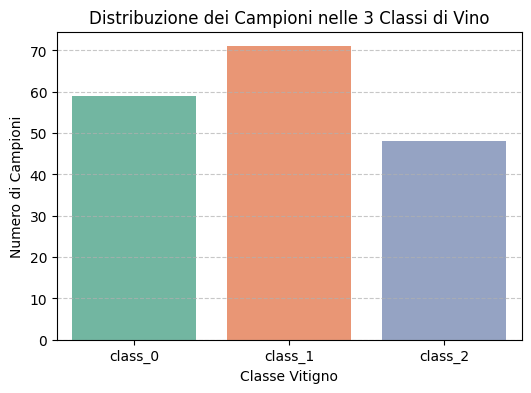

In [6]:
# 1. Creiamo un DataFrame completo (con anche la colonna Target) per l'analisi visiva
df_esplorazione = X.copy()
df_esplorazione['target'] = y

# 2. Visualizziamo le prime 5 righe per capire come si presentano i dati chimici
print("--- PRIME RIGHE DEL DATASET ---")
print(df_esplorazione.head())

# 3. Informazioni generali sui tipi di dati e la presenza di valori nulli
print("\n--- INFORMAZIONI SUL DATASET (Tipi e Valori Nulli) ---")
print(df_esplorazione.info())

# 4. Statistiche descrittive (Media, Deviazione Standard, Min, Max)
# Questo serve per capire la scala delle diverse feature (es. proline arriva a 1680, acidità a 0.74)
print("\n--- STATISTICHE DESCRITTIVE ---")
print(df_esplorazione.describe().T[['mean', 'std', 'min', 'max']])

# 5. Analisi del bilanciamento delle classi (Quanti vini ci sono per ogni vitigno?)
# Requisito minimo: verificare se il dataset è sbilanciato
print("\n--- DISTRIBUZIONE DELLE CLASSI (Vitigni 0, 1, 2) ---")
conteggio_classi = pd.Series(y).value_counts().sort_index()
for classe, qta in conteggio_classi.items():
    percentuale = (qta / len(y)) * 100
    print(f"Classe {classe} (Vitigno {wine_data.target_names[classe]}): {qta} campioni ({percentuale:.2f}%)")

# 6. Grafico della distribuzione delle classi (da salvare per la relazione!)
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette="Set2", legend=False)
plt.title("Distribuzione dei Campioni nelle 3 Classi di Vino")
plt.xlabel("Classe Vitigno")
plt.ylabel("Numero di Campioni")
plt.xticks(ticks=[0, 1, 2], labels=wine_data.target_names)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# PASSO 3: Apprendimento Non Supervisionato (Clustering e PCA)

In questa sezione applicheremo l'apprendimento non supervisionato seguendo questi step:
1. **Scelta di K**: Utilizzeremo il Metodo del Gomito (Inertia) e il Silhouette Score per motivare empiricamente la scelta del numero di cluster ottimali.
2. **Confronto degli Spazi**: Confronteremo l'applicazione del K-Means nello spazio delle feature standardizzate originale (13D) contro lo spazio ridotto dalla PCA (2D).
3. **Analisi Visiva**: Affiancheremo le previsioni del clustering alla *ground truth* (le classi reali) per una valutazione qualitativa iniziale.

--- RISULTATI PCA ---
Varianza spiegata dalle prime 2 componenti: 55.41%



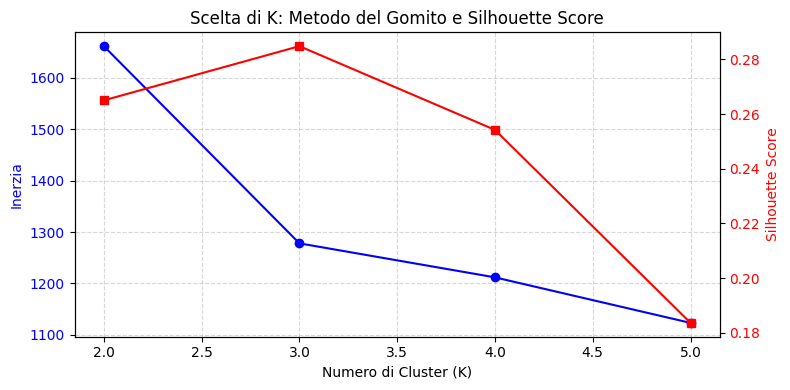

Silhouette Score (Spazio Originale Standardizzato): 0.285
Silhouette Score (Spazio PCA 2D): 0.560


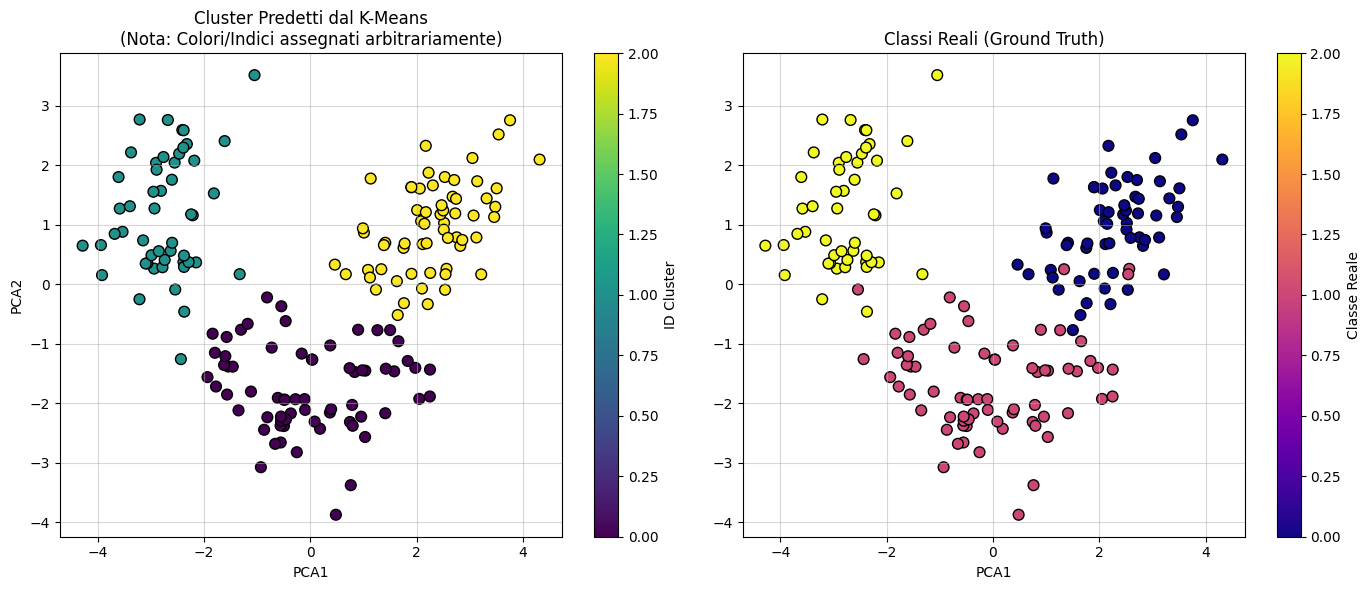


Shape di X (originale per Baseline): (178, 13)
Shape di X_augmented (con feature derivate): (178, 17)


In [8]:
from sklearn.metrics import silhouette_score

# --- 3.1 STANDARDIZZAZIONE E PCA ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("--- RISULTATI PCA ---")
print(f"Varianza spiegata dalle prime 2 componenti: {sum(pca.explained_variance_ratio_) * 100:.2f}%\n")

# --- 3.2 SCELTA MOTIVATA DI K (Elbow Method & Silhouette) ---
inertias = []
silhouette_scores = []
K_range = range(2, 6)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, inertias, marker='o', color='b', label='Inerzia (Elbow)')
ax1.set_xlabel('Numero di Cluster (K)')
ax1.set_ylabel('Inerzia', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, linestyle='--', alpha=0.5) # FIX: Griglia applicata solo all'asse principale

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, marker='s', color='r', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title("Scelta di K: Metodo del Gomito e Silhouette Score")
fig.tight_layout()
plt.show()

# --- 3.3 CONFRONTO: SPAZIO ORIGINALE vs SPAZIO PCA ---
k_opt = 3

kmeans_orig = KMeans(n_clusters=k_opt, random_state=42, n_init='auto')
labels_orig = kmeans_orig.fit_predict(X_scaled)
sil_orig = silhouette_score(X_scaled, labels_orig)

kmeans_pca = KMeans(n_clusters=k_opt, random_state=42, n_init='auto')
labels_pca = kmeans_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca)

print(f"Silhouette Score (Spazio Originale Standardizzato): {sil_orig:.3f}")
print(f"Silhouette Score (Spazio PCA 2D): {sil_pca:.3f}")

# --- 3.4 CONFRONTO VISIVO: CLUSTER PREDETTI VS CLASSI REALI ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# FIX: Aggiunta nota sui colori arbitrari
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='viridis', edgecolor='k', s=60)
axes[0].set_title("Cluster Predetti dal K-Means\n(Nota: Colori/Indici assegnati arbitrariamente)")
axes[0].set_xlabel("PCA1")
axes[0].set_ylabel("PCA2")
axes[0].grid(True, alpha=0.5)
plt.colorbar(sc1, ax=axes[0], label="ID Cluster") # FIX: Aggiunta colorbar

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', edgecolor='k', s=60)
axes[1].set_title("Classi Reali (Ground Truth)")
axes[1].set_xlabel("PCA1")
axes[1].grid(True, alpha=0.5)
plt.colorbar(sc2, ax=axes[1], label="Classe Reale") # FIX: Aggiunta colorbar

plt.tight_layout()
plt.show()

# --- 3.5 CREAZIONE DATASET AUMENTATO ---
# Raccogliamo tutto qui, ma nel Passo 4 useremo queste feature separatamente per gli esperimenti
X_augmented = X.copy()
X_augmented['Cluster_Label_Orig'] = labels_orig
X_augmented['Cluster_Label_PCA'] = labels_pca
X_augmented['PCA1'] = X_pca[:, 0]
X_augmented['PCA2'] = X_pca[:, 1]

print("\nShape di X (originale per Baseline):", X.shape)
print("Shape di X_augmented (con feature derivate):", X_augmented.shape)